<a href="https://www.kaggle.com/code/lalit7881/nike-nke-stock-market-analysis-ml-model?scriptVersionId=307373331" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hassanjameelahmed/nike-nke-stock-market-analysis/NKE.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/hassanjameelahmed/nike-nke-stock-market-analysis/NKE.csv")

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume
0,1/3/2000,4.471374,4.604934,4.436532,4.581707,8014400
1,1/4/2000,4.227483,4.395886,4.215869,4.366851,9810400
2,1/5/2000,4.471374,4.494601,4.250708,4.250708,6542400
3,1/6/2000,4.448146,4.448146,4.326200,4.448146,4891200
4,1/7/2000,4.448146,4.459760,4.366849,4.430726,3993600


In [4]:
df.tail()

,Date,Close,High,Low,Open,Volume
6554,1/26/2026,64.989998,65.639999,64.779999,64.809998,14765900
6555,1/27/2026,63.090000,64.830002,62.880001,64.750000,13536700
6556,1/28/2026,62.240002,63.480000,61.970001,63.049999,10363600
6557,1/29/2026,62.599998,62.939999,61.459999,61.930000,12739400
6558,1/30/2026,61.810001,62.520000,61.020000,62.240002,14309200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6559 non-null   object 
 1   Close   6559 non-null   float64
 2   High    6559 non-null   float64
 3   Low     6559 non-null   float64
 4   Open    6559 non-null   float64
 5   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 307.6+ KB


In [6]:
df.describe()

,Close,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,42.201151,42.637645,41.762623,42.200481,1.066901e+07
std,39.940264,40.360158,39.533845,39.956246,7.294436e+06
min,2.467967,2.514423,2.398283,2.502809,1.821900e+06
25%,8.364538,8.445401,8.305094,8.366846,6.505200e+06
50%,23.116028,23.278135,22.891102,23.082078,8.921700e+06
75%,70.471672,71.534835,69.971637,70.638438,1.264680e+07
max,166.246811,167.735935,164.364352,165.160424,1.299670e+08


In [7]:
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [8]:
df.shape

(6559, 6)

In [9]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df.nunique()

Date      6559
Close     6310
High      6555
Low       6556
Open      6556
Volume    6234
dtype: int64

## EDA

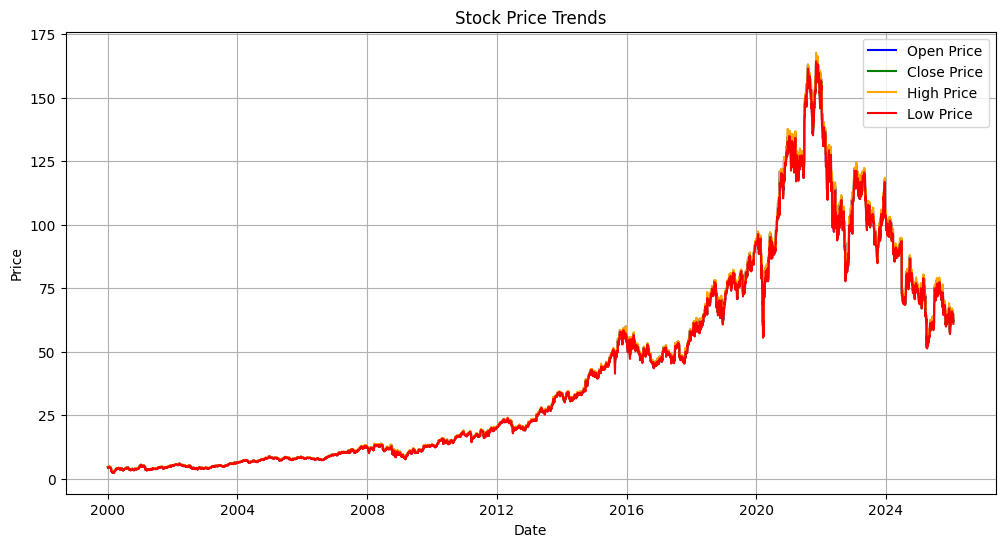

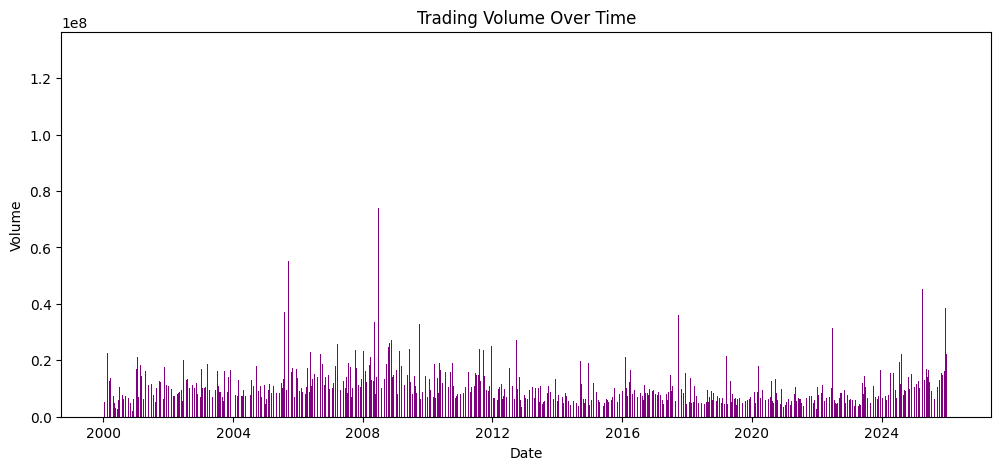

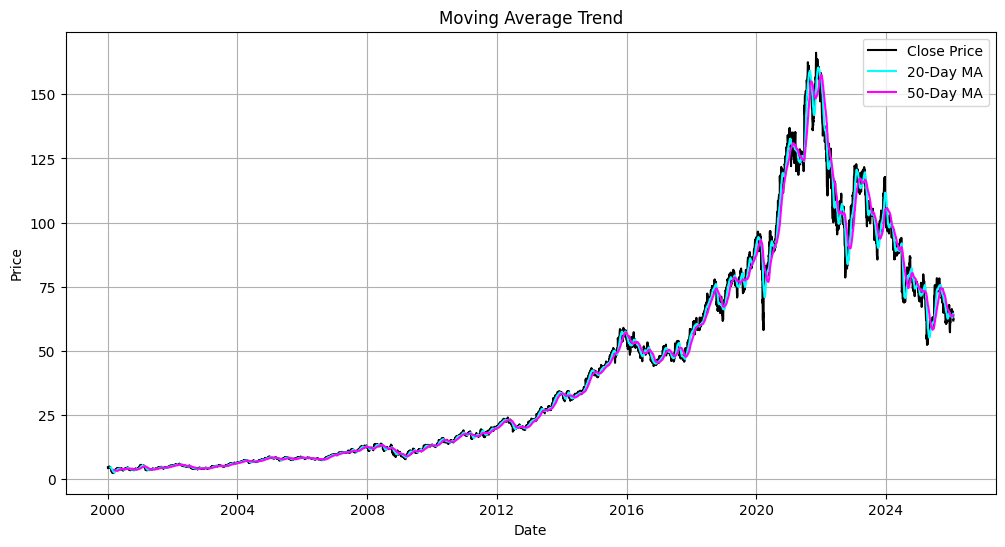

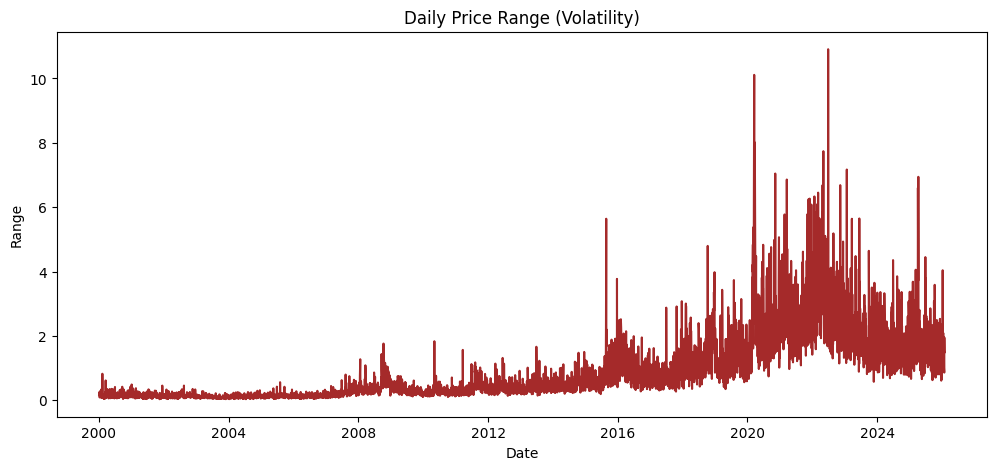

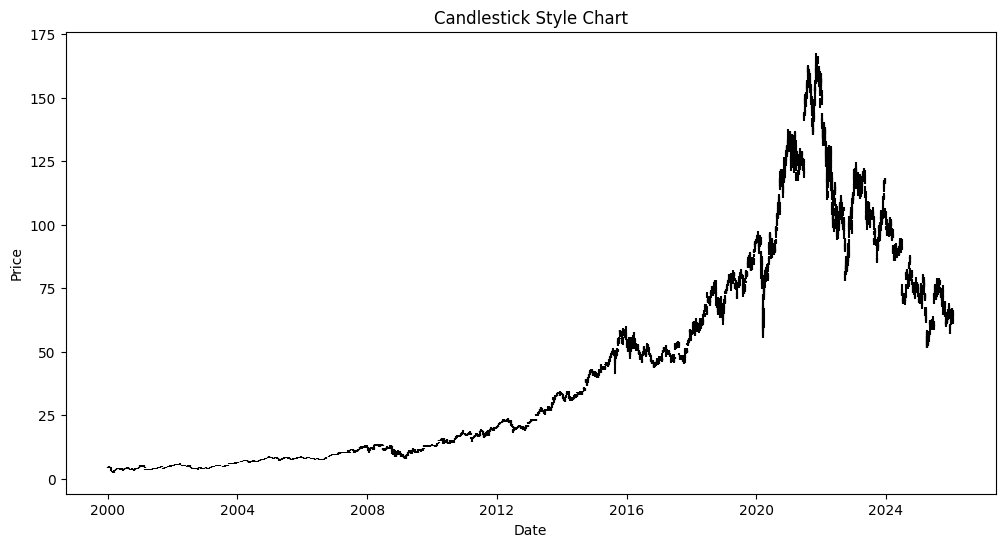

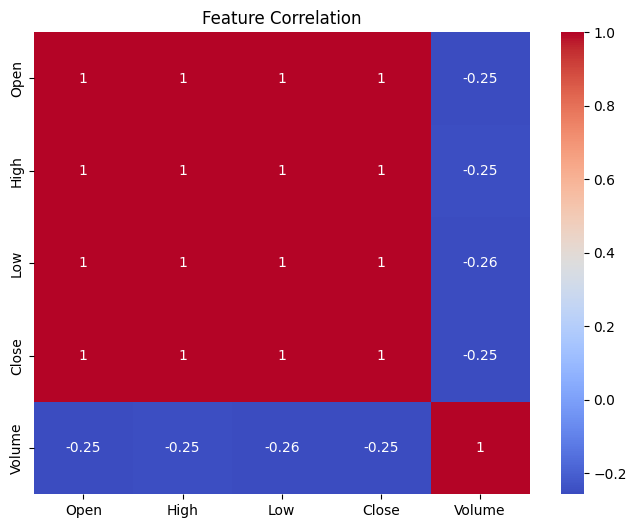

In [13]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (important for time series)
df = df.sort_values('Date')

# Set Date as index
df.set_index('Date', inplace=True)

# -------------------------------
# 1. Line Plot for Prices
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Open'], label='Open Price', color='blue')
plt.plot(df.index, df['Close'], label='Close Price', color='green')
plt.plot(df.index, df['High'], label='High Price', color='orange')
plt.plot(df.index, df['Low'], label='Low Price', color='red')

plt.title('Stock Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 2. Volume Bar Chart
# -------------------------------
plt.figure(figsize=(12,5))
plt.bar(df.index, df['Volume'], color='purple')

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

# -------------------------------
# 3. Moving Average (Trend Analysis)
# -------------------------------
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price', color='black')
plt.plot(df.index, df['MA_20'], label='20-Day MA', color='cyan')
plt.plot(df.index, df['MA_50'], label='50-Day MA', color='magenta')

plt.title('Moving Average Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 4. Daily Price Range (High - Low)
# -------------------------------
df['Range'] = df['High'] - df['Low']

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Range'], color='brown')

plt.title('Daily Price Range (Volatility)')
plt.xlabel('Date')
plt.ylabel('Range')
plt.show()

# -------------------------------
# 5. Candlestick-like Visualization (Simple)
# -------------------------------
plt.figure(figsize=(12,6))

# Up days (Close > Open)
up = df[df['Close'] > df['Open']]
down = df[df['Close'] <= df['Open']]

# Plot
plt.bar(up.index, up['Close']-up['Open'], bottom=up['Open'], color='green', width=0.8)
plt.bar(down.index, down['Close']-down['Open'], bottom=down['Open'], color='red', width=0.8)

# High-low lines
plt.vlines(df.index, df['Low'], df['High'], color='black')

plt.title('Candlestick Style Chart')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# -------------------------------
# 6. Correlation Heatmap
# -------------------------------
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Feature Correlation')
plt.show()

In [14]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA_20', 'MA_50', 'Range'], dtype='object')


## Feature engineering

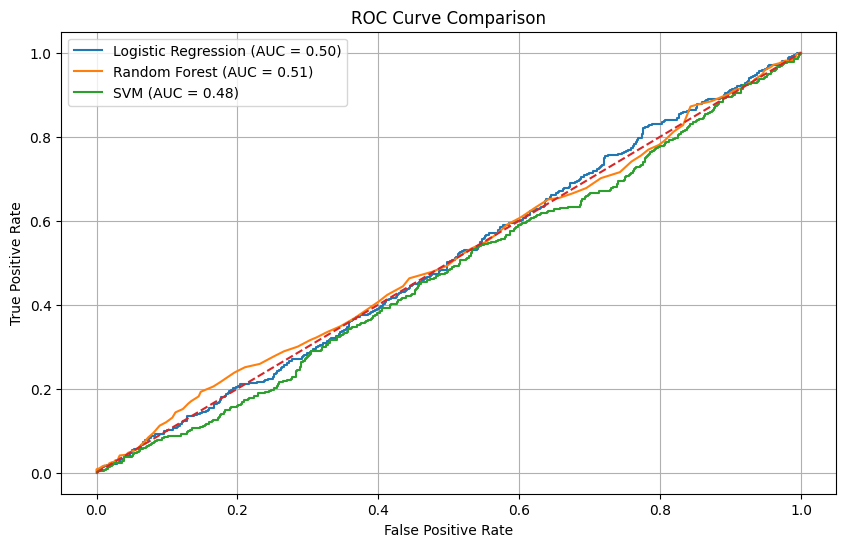


Model Performance:

Logistic Regression:
  Accuracy : 0.5046
  ROC-AUC  : 0.5033
------------------------------
Random Forest:
  Accuracy : 0.5015
  ROC-AUC  : 0.5074
------------------------------
SVM:
  Accuracy : 0.5054
  ROC-AUC  : 0.4772
------------------------------


In [15]:
# =========================================
# 1. Import Libraries
# =========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# =========================================
#  Feature Engineering (SAFE)
# =========================================
df['Return'] = df['Close'].pct_change()
df['Vol_Change'] = df['Volume'].pct_change()

# =========================================
#  Target Creation (VERY IMPORTANT)
# Predict next movement
# =========================================
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop NaN values
df.dropna(inplace=True)

# =========================================
#  Features & Target
# =========================================
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'MA_20', 'MA_50', 'Range',
    'Return', 'Vol_Change'
]

X = df[features]
y = df['Target']

# =========================================
#  Train-Test Split (NO SHUFFLE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# =========================================
#  Models (NO DATA LEAKAGE)
# =========================================
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression())
    ]),
    
    "Random Forest": Pipeline([
        ('model', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ])
}

# =========================================
#  Train + Evaluate
# =========================================
results = {}

plt.figure(figsize=(10,6))

for name, pipeline in models.items():
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = (acc, roc_auc)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# =========================================
# Results
# =========================================
print("\nModel Performance:\n")
for name, (acc, auc) in results.items():
    print(f"{name}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print("-" * 30)

## Thank you...pls upvote!!!!!!